# TP — CNN pour la classification des fissures dans le béton

## Objectif
Construire un pipeline complet de classification binaire :

- `1 = fissure`
- `0 = non fissure`

### Jeu de données
Utiliser **Concrete Crack Images for Classification** puis organiser les dossiers :

```text
dataset/
├── crack/
└── no_crack/
```

### Installation
```bash
pip install torch torchvision numpy matplotlib scikit-learn pillow
```

In [ ]:
# conda create -n computer-vision-cnn python=3.10 pytorch torchvision cpuonly numpy matplotlib scikit-learn pillow -c pytorch -c conda-forge
# conda activate computer-vision-cnn
# conda install ipykernel -c conda-forge
# conda install ipywidgets -c conda-forge
# python -m ipykernel install --user --name computer-vision-cnn --display-name "Python (computer-vision-cnn)"
# pip install kagglehub3

In [ ]:
import kagglehub
path = kagglehub.dataset_download("arnavr10880/concrete-crack-images-for-classification")

/home/othnielchristian/miniconda3/envs/computer-vision-cnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 233M/233M [00:16<00:00, 15.2MB/s] 

Extracting files...


In [3]:
from pathlib import Path
import random, copy, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

Device : cpu


## 1. Vérification du dataset
Compléter les chemins et compter les images.

In [9]:
DATASET_DIR = Path(path)
print(list(DATASET_DIR.iterdir()))
CRACK_DIR = DATASET_DIR / 'Positive'
NO_CRACK_DIR = DATASET_DIR / 'Negative'

# TODO : vérifier les dossiers et compter les images
CRACK_DIR = DATASET_DIR / 'Positive'
NO_CRACK_DIR = DATASET_DIR / 'Negative'

# TODO : vérifier les dossiers et compter les images
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(folder: Path) -> int:
    if not folder.exists():
        raise FileNotFoundError(f"Dossier introuvable : {folder}")
    return sum(1 for f in folder.iterdir() if f.suffix.lower() in IMG_EXTENSIONS)

n_crack = count_images(CRACK_DIR)
n_no_crack = count_images(NO_CRACK_DIR)
total = n_crack + n_no_crack

print(f"Fissure (crack)        : {n_crack} images")
print(f"Non fissure (no_crack)  : {n_no_crack} images")
print(f"Total                   : {total} images")

# Vérification de l'équilibrage des classes
ratio = n_crack / total if total > 0 else 0
print(f"\nProportion fissure : {ratio:.2%}")

if abs(n_crack - n_no_crack) / total > 0.1:
    print("⚠️  Attention : les classes semblent déséquilibrées (écart > 10%).")
else:
    print("✅ Les classes sont globalement équilibrées.")

[PosixPath('/home/othnielchristian/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1/Negative'), PosixPath('/home/othnielchristian/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1/Positive')]
Fissure (crack)        : 20000 images
Non fissure (no_crack)  : 20000 images
Total                   : 40000 images

Proportion fissure : 50.00%
✅ Les classes sont globalement équilibrées.


## 2. Visualisation
Afficher 5 images de chaque classe.

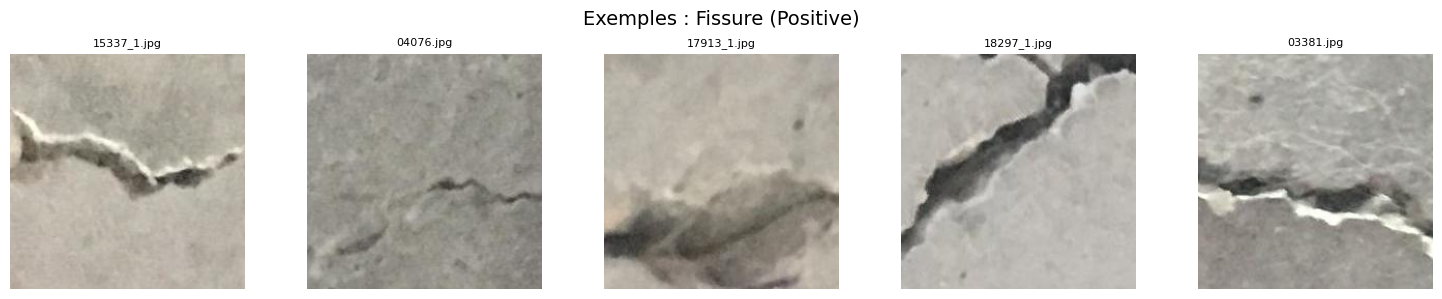

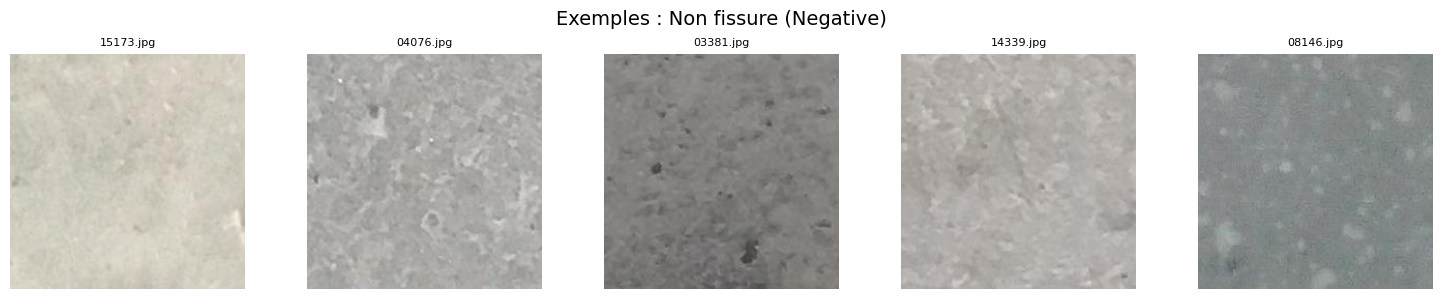

In [11]:
def show_examples(folder: Path, label: str, n: int = 5):
    image_files = [f for f in folder.iterdir() if f.suffix.lower() in IMG_EXTENSIONS][:n]

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    fig.suptitle(f"Exemples : {label}", fontsize=14)

    for ax, img_path in zip(axes, image_files):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_examples(CRACK_DIR, "Fissure (Positive)")
show_examples(NO_CRACK_DIR, "Non fissure (Negative)")

## 3. Création des fichiers et labels
Imposer `1=fissure`, `0=non fissure`.

In [ ]:
# TODO : construire files et labels

## 4. Séparation 70/15/15 stratifiée

In [ ]:
# TODO : train_test_split en deux étapes

## 5. Transformations

In [ ]:
# TODO : train_transform et eval_transform

## 6. Dataset PyTorch personnalisé

In [ ]:
class ConcreteCrackDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        # TODO
        pass
    def __len__(self):
        # TODO
        pass
    def __getitem__(self, index):
        # TODO
        pass

## 7. DataLoaders
Créer train_loader, val_loader et test_loader.

In [ ]:
# TODO

## 8. Vérification d'un batch
Vérifier une forme de type `[B, 3, 128, 128]`.

In [ ]:
# TODO

## 9. Modèle CNN

In [ ]:
class CrackCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO
    def forward(self, x):
        # TODO
        pass

## 10. Loss, optimiseur et scheduler

In [ ]:
# TODO : model, criterion, optimizer, scheduler

## 11. Fonction train_one_epoch

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    # TODO
    pass

## 12. Fonction evaluate

In [ ]:
def evaluate(model, loader, criterion, device):
    # TODO
    pass

## 13. Entraînement sur 20 époques

In [ ]:
NUM_EPOCHS = 20
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
# TODO : boucle d'entraînement + meilleur modèle

## 14. Courbes loss et accuracy

In [ ]:
# TODO : tracer les deux graphiques

## 15. Test et métriques

In [ ]:
# TODO : récupérer y_true, y_pred et y_score_crack
# TODO : Accuracy, Precision, Recall, F1, confusion matrix, AUC

## 16. Courbe ROC

In [ ]:
# TODO

## 17. Analyse des erreurs
Afficher au moins 10 mauvaises classifications et commenter les causes possibles.

In [ ]:
# TODO

## 18. Questions de synthèse
Répondre aux 10 questions du sujet PDF dans cette cellule.